<a href="https://colab.research.google.com/github/shoh0806/Deep-Learning-Project/blob/main/Final_Project_Clickbait_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal YouTube Clickbait Detection
## BERT · ViT · Late Fusion · Cross-Attention

**Task:** Classify a YouTube video as Clickbait (1) or Non-Clickbait (0)  
using **title text** (BERT) + **thumbnail image** (ViT).

| Model | Modality |
|---|---|
| BERT | Text only |
| ViT | Image only |
| Late Fusion | Text + Image (concatenation) |
| **Cross-Attention** | Text + Image (bidirectional attention) ← proposed |


## 1. Setup

In [1]:
!pip install transformers accelerate -q

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer, BertModel,
    ViTModel, ViTImageProcessor
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device} | Seed : {SEED}")


Device : cuda | Seed : 42


## 2. Google Drive & Data

In [3]:
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/clickbait_project"
CSV_PATH = f"{BASE_DIR}/dataset.csv"
IMG_DIR  = f"{BASE_DIR}/thumbnails"

df = pd.read_csv(CSV_PATH)
df["label"] = df["label"].astype(int)

print(f"Total         : {len(df)}")
print(f"Clickbait (1) : {(df['label']==1).sum()}")
print(f"Non-Clickbait : {(df['label']==0).sum()}")
df.head()


Mounted at /content/drive
Total         : 2512
Clickbait (1) : 1110
Non-Clickbait : 1402


,video_id,title,thumbnail_path,label
0,lepHJI4ze-w,I Bought 250 BANNED Amazon Products!,thumbnails/lepHJI4ze-w.jpg,1
1,ezwXAlJ5pAY,TikTok Wigofellas PRANKS on MOM - Wigofellas P...,thumbnails/ezwXAlJ5pAY.jpg,1
2,i6_OomloWUg,TikTok Wigofellas PRANKS on MOM - Wigofellas P...,thumbnails/i6_OomloWUg.jpg,1
3,VvuuR7HifUY,Superheroes in Real Life Caught On Camera !,thumbnails/VvuuR7HifUY.jpg,1
4,uwIjrEbywnk,20 People You Won't Believe Existed Till You S...,thumbnails/uwIjrEbywnk.jpg,1


## 3. Data Split (80 / 10 / 10)

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")


Train : 2009
Val   : 251
Test  : 252


## 4. Pretrained Models & Shared Utilities

In [5]:
TEXT_MODEL_NAME  = "bert-base-multilingual-cased"
IMAGE_MODEL_NAME = "google/vit-base-patch16-224"

tokenizer       = BertTokenizer.from_pretrained(TEXT_MODEL_NAME)
image_processor = ViTImageProcessor.from_pretrained(IMAGE_MODEL_NAME)

EPOCHS  = 10
PATIENCE = 3

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params     : {total:,}")
    print(f"  Trainable params : {trainable:,}")

def freeze_backbone_except_last_layers(model, bert_unfreeze_layers=2, vit_unfreeze_blocks=2):
    """Freeze BERT & ViT; keep only the last N layers trainable."""
    for p in model.bert.parameters(): p.requires_grad = False
    for layer in model.bert.encoder.layer[-bert_unfreeze_layers:]:
        for p in layer.parameters(): p.requires_grad = True

    for p in model.vit.parameters(): p.requires_grad = False
    for layer in model.vit.encoder.layer[-vit_unfreeze_blocks:]:
        for p in layer.parameters(): p.requires_grad = True
    if hasattr(model.vit, "layernorm"):
        for p in model.vit.layernorm.parameters(): p.requires_grad = True

print("Tokenizer & Image Processor ready.")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Tokenizer & Image Processor ready.


---
## 5. BERT — Text-Only Baseline

Encodes the video **title** with `bert-base-multilingual-cased`  
and classifies via the `[CLS]` token representation.


### 5-1. Dataset & DataLoader

In [6]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df["title"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

bert_train_loader = DataLoader(TextDataset(train_df, tokenizer), batch_size=32, shuffle=True)
bert_val_loader   = DataLoader(TextDataset(val_df,   tokenizer), batch_size=32)
bert_test_loader  = DataLoader(TextDataset(test_df,  tokenizer), batch_size=32)
print("BERT DataLoaders ready.")


BERT DataLoaders ready.


### 5-2. Model Definition

In [7]:
class BertClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert       = BertModel.from_pretrained(TEXT_MODEL_NAME)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls))

bert_model = BertClassifier().to(device)
count_params(bert_model)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Total params     : 177,854,978
  Trainable params : 177,854,978


### 5-3. Training

In [8]:
def bert_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds, targets = 0, [], []
    for batch in loader:
        ids, mask, lbls = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        out  = model(ids, mask)
        loss = criterion(out, lbls); loss.backward(); optimizer.step()
        total_loss += loss.item()
        preds += out.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    return total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds)

def bert_eval_epoch(model, loader, criterion):
    model.eval(); total_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask, lbls = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["label"].to(device)
            out  = model(ids, mask); loss = criterion(out, lbls)
            total_loss += loss.item()
            preds += out.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    return total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds)

bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=3e-5)
bert_criterion = nn.CrossEntropyLoss()
BERT_SAVE = f"{BASE_DIR}/bert_best.pt"

best_f1, patience_cnt = 0, 0
for epoch in range(EPOCHS):
    tl, tf, ta = bert_train_epoch(bert_model, bert_train_loader, bert_optimizer, bert_criterion)
    vl, vf, va = bert_eval_epoch(bert_model, bert_val_loader, bert_criterion)
    print(f"[BERT] Epoch {epoch+1}/{EPOCHS}  train f1:{tf:.4f} acc:{ta:.4f}  val f1:{vf:.4f} acc:{va:.4f}")
    if vf > best_f1:
        best_f1 = vf; patience_cnt = 0
        torch.save(bert_model.state_dict(), BERT_SAVE); print("  → saved")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE: print("  → Early stopping"); break


[BERT] Epoch 1/10  train f1:0.7448 acc:0.7501  val f1:0.8297 acc:0.8327
  → saved
[BERT] Epoch 2/10  train f1:0.8343 acc:0.8362  val f1:0.8597 acc:0.8606
  → saved
[BERT] Epoch 3/10  train f1:0.9064 acc:0.9074  val f1:0.8549 acc:0.8566
[BERT] Epoch 4/10  train f1:0.9552 acc:0.9557  val f1:0.8723 acc:0.8725
  → saved
[BERT] Epoch 5/10  train f1:0.9688 acc:0.9691  val f1:0.8677 acc:0.8685
[BERT] Epoch 6/10  train f1:0.9728 acc:0.9731  val f1:0.8745 acc:0.8765
  → saved
[BERT] Epoch 7/10  train f1:0.9899 acc:0.9900  val f1:0.8919 acc:0.8924
  → saved
[BERT] Epoch 8/10  train f1:0.9879 acc:0.9881  val f1:0.8804 acc:0.8805
[BERT] Epoch 9/10  train f1:0.9879 acc:0.9881  val f1:0.8694 acc:0.8725
[BERT] Epoch 10/10  train f1:0.9894 acc:0.9895  val f1:0.9157 acc:0.9163
  → saved


### 5-4. Test Result

In [9]:
bert_model.load_state_dict(torch.load(BERT_SAVE, map_location=device))
_, bert_f1, bert_acc = bert_eval_epoch(bert_model, bert_test_loader, bert_criterion)
print("========== BERT Test ==========")
print(f"F1  : {bert_f1:.4f}")
print(f"Acc : {bert_acc:.4f}")
bert_result = {"F1": bert_f1, "Acc": bert_acc}


========== BERT Test ==========
F1  : 0.8949
Acc : 0.8968


---
## 6. ViT — Image-Only Baseline

Encodes the **thumbnail** with `google/vit-base-patch16-224`  
and classifies via the `[CLS]` patch token.


### 6-1. Dataset & DataLoader

In [10]:
class ImageDataset(Dataset):
    def __init__(self, df, image_processor, img_dir):
        self.video_ids = df["video_id"].tolist()
        self.labels    = df["label"].tolist()
        self.ip = image_processor; self.img_dir = img_dir

    def __len__(self): return len(self.video_ids)

    def __getitem__(self, idx):
        img = Image.open(f"{self.img_dir}/{self.video_ids[idx]}.jpg").convert("RGB")
        pv  = self.ip(images=img, return_tensors="pt")["pixel_values"].squeeze()
        return {"pixel_values": pv, "label": torch.tensor(self.labels[idx], dtype=torch.long)}

vit_train_loader = DataLoader(ImageDataset(train_df, image_processor, IMG_DIR), batch_size=32, shuffle=True)
vit_val_loader   = DataLoader(ImageDataset(val_df,   image_processor, IMG_DIR), batch_size=32)
vit_test_loader  = DataLoader(ImageDataset(test_df,  image_processor, IMG_DIR), batch_size=32)
print("ViT DataLoaders ready.")


ViT DataLoaders ready.


### 6-2. Model Definition

In [11]:
class ViTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit        = ViTModel.from_pretrained(IMAGE_MODEL_NAME)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 2)

    def forward(self, pixel_values):
        cls = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls))

vit_model = ViTClassifier().to(device)
count_params(vit_model)


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params     : 86,390,786
  Trainable params : 86,390,786


### 6-3. Training

In [12]:
def vit_train_epoch(model, loader, optimizer, criterion):
    model.train(); total_loss, preds, targets = 0, [], []
    for batch in loader:
        pv, lbls = batch["pixel_values"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        out = model(pv); loss = criterion(out, lbls); loss.backward(); optimizer.step()
        total_loss += loss.item()
        preds += out.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    return total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds)

def vit_eval_epoch(model, loader, criterion):
    model.eval(); total_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for batch in loader:
            pv, lbls = batch["pixel_values"].to(device), batch["label"].to(device)
            out = model(pv); loss = criterion(out, lbls)
            total_loss += loss.item()
            preds += out.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    return total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds)

vit_optimizer = torch.optim.AdamW(vit_model.parameters(), lr=3e-5)
vit_criterion = nn.CrossEntropyLoss()
VIT_SAVE = f"{BASE_DIR}/vit_best.pt"

best_f1, patience_cnt = 0, 0
for epoch in range(EPOCHS):
    tl, tf, ta = vit_train_epoch(vit_model, vit_train_loader, vit_optimizer, vit_criterion)
    vl, vf, va = vit_eval_epoch(vit_model, vit_val_loader, vit_criterion)
    print(f"[ViT] Epoch {epoch+1}/{EPOCHS}  train f1:{tf:.4f} acc:{ta:.4f}  val f1:{vf:.4f} acc:{va:.4f}")
    if vf > best_f1:
        best_f1 = vf; patience_cnt = 0
        torch.save(vit_model.state_dict(), VIT_SAVE); print("  → saved")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE: print("  → Early stopping"); break


[ViT] Epoch 1/10  train f1:0.7265 acc:0.7317  val f1:0.8304 acc:0.8327
  → saved
[ViT] Epoch 2/10  train f1:0.9237 acc:0.9248  val f1:0.8697 acc:0.8725
  → saved
[ViT] Epoch 3/10  train f1:0.9904 acc:0.9905  val f1:0.8654 acc:0.8685
[ViT] Epoch 4/10  train f1:0.9980 acc:0.9980  val f1:0.8710 acc:0.8725
  → saved
[ViT] Epoch 5/10  train f1:1.0000 acc:1.0000  val f1:0.8664 acc:0.8685
[ViT] Epoch 6/10  train f1:1.0000 acc:1.0000  val f1:0.8712 acc:0.8725
  → saved
[ViT] Epoch 7/10  train f1:1.0000 acc:1.0000  val f1:0.8752 acc:0.8765
  → saved
[ViT] Epoch 8/10  train f1:1.0000 acc:1.0000  val f1:0.8749 acc:0.8765
[ViT] Epoch 9/10  train f1:1.0000 acc:1.0000  val f1:0.8749 acc:0.8765
[ViT] Epoch 10/10  train f1:1.0000 acc:1.0000  val f1:0.8708 acc:0.8725
  → Early stopping


### 6-4. Test Result

In [13]:
vit_model.load_state_dict(torch.load(VIT_SAVE, map_location=device))
_, vit_f1, vit_acc = vit_eval_epoch(vit_model, vit_test_loader, vit_criterion)
print("========== ViT Test ==========")
print(f"F1  : {vit_f1:.4f}")
print(f"Acc : {vit_acc:.4f}")
vit_result = {"F1": vit_f1, "Acc": vit_acc}


========== ViT Test ==========
F1  : 0.8921
Acc : 0.8929


---
## 7. Multimodal Dataset
Shared by **Late Fusion** and **Cross-Attention** — returns both text tokens and image pixel values.


In [14]:
class MultimodalDataset(Dataset):
    def __init__(self, df, tokenizer, image_processor, img_dir, max_len=128):
        self.df  = df.reset_index(drop=True)
        self.tok = tokenizer; self.ip = image_processor
        self.img_dir = img_dir; self.max_len = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        title = str(row["title"]); label = int(row["label"])

        enc = self.tok(title, max_length=self.max_len, padding="max_length",
                       truncation=True, return_tensors="pt")
        img = Image.open(f"{self.img_dir}/{row['video_id']}.jpg").convert("RGB")
        pv  = self.ip(images=img, return_tensors="pt")["pixel_values"].squeeze(0)

        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "pixel_values":   pv,
            "label":          torch.tensor(label, dtype=torch.long)
        }

g = torch.Generator(); g.manual_seed(SEED)
MM_BATCH = 16
mm_train_loader = DataLoader(MultimodalDataset(train_df, tokenizer, image_processor, IMG_DIR),
                             batch_size=MM_BATCH, shuffle=True,
                             worker_init_fn=seed_worker, generator=g, num_workers=0)
mm_val_loader   = DataLoader(MultimodalDataset(val_df,   tokenizer, image_processor, IMG_DIR),
                             batch_size=MM_BATCH, shuffle=False, num_workers=0)
mm_test_loader  = DataLoader(MultimodalDataset(test_df,  tokenizer, image_processor, IMG_DIR),
                             batch_size=MM_BATCH, shuffle=False, num_workers=0)
print(f"Multimodal DataLoaders ready (batch={MM_BATCH}).")


Multimodal DataLoaders ready (batch=16).


---
## 8. Late Fusion

Concatenates BERT `[CLS]` (768-d) and ViT `[CLS]` (768-d) → MLP → 2-class output.  
Only the **last 2 layers** of each backbone are fine-tuned.


### 8-1. Model Definition

In [15]:
class LateFusionClassifier(nn.Module):
    def __init__(self, hidden_dim=256, dropout_rate=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(TEXT_MODEL_NAME)
        self.vit  = ViTModel.from_pretrained(IMAGE_MODEL_NAME)
        freeze_backbone_except_last_layers(self)

        self.dropout    = nn.Dropout(dropout_rate)
        self.fc1        = nn.Linear(768 + 768, hidden_dim)
        self.relu       = nn.ReLU()
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, input_ids, attention_mask, pixel_values):
        text_cls  = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        image_cls = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        x = self.dropout(torch.cat([text_cls, image_cls], dim=1))
        x = self.relu(self.fc1(x))
        return self.classifier(self.dropout(x))

lf_model = LateFusionClassifier().to(device)
count_params(lf_model)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params     : 264,636,674
  Trainable params : 28,747,010


### 8-2. Training

In [16]:
def mm_train_epoch(model, loader, optimizer, criterion):
    model.train(); total_loss, preds, targets = 0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        pv   = batch["pixel_values"].to(device)
        lbls = batch["label"].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, pixel_values=pv)
        loss = criterion(out, lbls); loss.backward(); optimizer.step()
        total_loss += loss.item()
        preds += out.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    return total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds)

def mm_eval_epoch(model, loader, criterion, return_preds=False):
    model.eval(); total_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            pv   = batch["pixel_values"].to(device)
            lbls = batch["label"].to(device)
            out  = model(input_ids=ids, attention_mask=mask, pixel_values=pv)
            loss = criterion(out, lbls)
            total_loss += loss.item()
            preds += out.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    res = (total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds))
    return res + (preds, targets) if return_preds else res

lf_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, lf_model.parameters()), lr=3e-5)
lf_criterion = nn.CrossEntropyLoss()
LF_SAVE = f"{BASE_DIR}/late_fusion_best.pt"

best_f1, patience_cnt = 0, 0
for epoch in range(EPOCHS):
    tl, tf, ta = mm_train_epoch(lf_model, mm_train_loader, lf_optimizer, lf_criterion)
    vl, vf, va = mm_eval_epoch(lf_model, mm_val_loader, lf_criterion)
    print(f"[LF] Epoch {epoch+1}/{EPOCHS}  train f1:{tf:.4f} acc:{ta:.4f}  val f1:{vf:.4f} acc:{va:.4f}")
    if vf > best_f1:
        best_f1 = vf; patience_cnt = 0
        torch.save(lf_model.state_dict(), LF_SAVE); print("  → saved")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE: print("  → Early stopping"); break


[LF] Epoch 1/10  train f1:0.7498 acc:0.7556  val f1:0.8315 acc:0.8327
  → saved
[LF] Epoch 2/10  train f1:0.8605 acc:0.8621  val f1:0.8661 acc:0.8685
  → saved
[LF] Epoch 3/10  train f1:0.9037 acc:0.9049  val f1:0.8760 acc:0.8765
  → saved
[LF] Epoch 4/10  train f1:0.9405 acc:0.9413  val f1:0.8784 acc:0.8805
  → saved
[LF] Epoch 5/10  train f1:0.9687 acc:0.9691  val f1:0.8793 acc:0.8805
  → saved
[LF] Epoch 6/10  train f1:0.9848 acc:0.9851  val f1:0.8867 acc:0.8884
  → saved
[LF] Epoch 7/10  train f1:0.9970 acc:0.9970  val f1:0.8954 acc:0.8964
  → saved
[LF] Epoch 8/10  train f1:0.9985 acc:0.9985  val f1:0.9033 acc:0.9044
  → saved
[LF] Epoch 9/10  train f1:0.9995 acc:0.9995  val f1:0.8948 acc:0.8964
[LF] Epoch 10/10  train f1:1.0000 acc:1.0000  val f1:0.9031 acc:0.9044


### 8-3. Test Result

In [17]:
lf_model.load_state_dict(torch.load(LF_SAVE, map_location=device))
_, lf_f1, lf_acc, lf_preds, lf_targets = mm_eval_epoch(lf_model, mm_test_loader, lf_criterion, return_preds=True)
print("========== Late Fusion Test ==========")
print(f"F1  : {lf_f1:.4f}")
print(f"Acc : {lf_acc:.4f}")
print(classification_report(lf_targets, lf_preds, target_names=["Non-Clickbait","Clickbait"], digits=4))
lf_result = {"F1": lf_f1, "Acc": lf_acc}


========== Late Fusion Test ==========
F1  : 0.9113
Acc : 0.9127
               precision    recall  f1-score   support

Non-Clickbait     0.9161    0.9291    0.9225       141
    Clickbait     0.9083    0.8919    0.9000       111

     accuracy                         0.9127       252
    macro avg     0.9122    0.9105    0.9113       252
 weighted avg     0.9126    0.9127    0.9126       252



---
## 9. Cross-Attention (Proposed Model)

**Bidirectional cross-modal attention:**  
- Text → Image : text token sequence attends over image patch tokens  
- Image → Text : image patch sequence attends over text tokens  

Final: `cat([text_cls, image_cls, t2i_cls, i2t_cls])` → 4×768 → classifier


### 9-1. Model Definition

In [18]:
class CrossAttentionClickbaitModel(nn.Module):
    def __init__(self, hidden_size=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(TEXT_MODEL_NAME)
        self.vit  = ViTModel.from_pretrained(IMAGE_MODEL_NAME)

        self.text_to_image_attn = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.image_to_text_attn = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.norm_t2i = nn.LayerNorm(hidden_size)
        self.norm_i2t = nn.LayerNorm(hidden_size)
        self.dropout  = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 4, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2)
        )
        freeze_backbone_except_last_layers(self)

    def forward(self, input_ids, attention_mask, pixel_values):
        text_h  = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        image_h = self.vit(pixel_values=pixel_values).last_hidden_state

        text_cls  = text_h[:, 0, :]
        image_cls = image_h[:, 0, :]

        pad_mask = (attention_mask == 0)

        t2i_out, t2i_w = self.text_to_image_attn(
            query=text_h, key=image_h, value=image_h,
            need_weights=True, average_attn_weights=True)
        i2t_out, i2t_w = self.image_to_text_attn(
            query=image_h, key=text_h, value=text_h,
            key_padding_mask=pad_mask,
            need_weights=True, average_attn_weights=True)

        t2i_out = self.norm_t2i(t2i_out + text_h)
        i2t_out = self.norm_i2t(i2t_out + image_h)

        fused  = torch.cat([text_cls, image_cls, t2i_out[:, 0, :], i2t_out[:, 0, :]], dim=1)
        logits = self.classifier(self.dropout(fused))
        return logits, t2i_w, i2t_w

ca_model = CrossAttentionClickbaitModel().to(device)
count_params(ca_model)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params     : 271,332,098
  Trainable params : 35,442,434


### 9-2. Load Pre-trained BERT / ViT Weights

In [19]:
def load_backbone_weights(model, base_dir):
    for name, path_key, prefix in [("BERT", "bert_best.pt", "bert."),
                                    ("ViT",  "vit_best.pt",  "vit.")]:
        path = f"{base_dir}/{path_key}"
        if os.path.exists(path):
            state = torch.load(path, map_location="cpu")
            sub   = {k[len(prefix):]: v for k, v in state.items() if k.startswith(prefix)}
            getattr(model, name.lower()).load_state_dict(sub, strict=False)
            print(f"{name} fine-tuned weights loaded.")
        else:
            print(f"{name} weights not found — using pretrained.")

load_backbone_weights(ca_model, BASE_DIR)


BERT fine-tuned weights loaded.
ViT fine-tuned weights loaded.


### 9-3. Training

In [20]:
def ca_train_epoch(model, loader, optimizer, criterion):
    model.train(); total_loss, preds, targets = 0, [], []
    for batch in loader:
        ids, mask, pv, lbls = (batch["input_ids"].to(device), batch["attention_mask"].to(device),
                                batch["pixel_values"].to(device), batch["label"].to(device))
        optimizer.zero_grad()
        logits, _, _ = model(input_ids=ids, attention_mask=mask, pixel_values=pv)
        loss = criterion(logits, lbls); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds += logits.argmax(1).detach().cpu().tolist(); targets += lbls.cpu().tolist()
    return total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds)

def ca_eval_epoch(model, loader, criterion, return_preds=False):
    model.eval(); total_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask, pv, lbls = (batch["input_ids"].to(device), batch["attention_mask"].to(device),
                                    batch["pixel_values"].to(device), batch["label"].to(device))
            logits, _, _ = model(input_ids=ids, attention_mask=mask, pixel_values=pv)
            loss = criterion(logits, lbls)
            total_loss += loss.item()
            preds += logits.argmax(1).cpu().tolist(); targets += lbls.cpu().tolist()
    res = (total_loss/len(loader), f1_score(targets, preds, average="macro"), accuracy_score(targets, preds))
    return res + (preds, targets) if return_preds else res

ca_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, ca_model.parameters()), lr=3e-5, weight_decay=0)
ca_criterion = nn.CrossEntropyLoss()
CA_SAVE = f"{BASE_DIR}/cross_attention_best.pt"

best_f1, patience_cnt = 0, 0
for epoch in range(EPOCHS):
    tl, tf, ta = ca_train_epoch(ca_model, mm_train_loader, ca_optimizer, ca_criterion)
    vl, vf, va = ca_eval_epoch(ca_model, mm_val_loader, ca_criterion)
    print(f"[CA] Epoch {epoch+1}/{EPOCHS}  train f1:{tf:.4f} acc:{ta:.4f}  val f1:{vf:.4f} acc:{va:.4f}")
    if vf > best_f1:
        best_f1 = vf; patience_cnt = 0
        torch.save(ca_model.state_dict(), CA_SAVE); print("  → saved")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE: print("  → Early stopping"); break


[CA] Epoch 1/10  train f1:0.9934 acc:0.9935  val f1:0.9039 acc:0.9044
  → saved
[CA] Epoch 2/10  train f1:1.0000 acc:1.0000  val f1:0.9276 acc:0.9283
  → saved
[CA] Epoch 3/10  train f1:1.0000 acc:1.0000  val f1:0.9395 acc:0.9402
  → saved
[CA] Epoch 4/10  train f1:1.0000 acc:1.0000  val f1:0.9396 acc:0.9402
  → saved
[CA] Epoch 5/10  train f1:1.0000 acc:1.0000  val f1:0.9396 acc:0.9402
[CA] Epoch 6/10  train f1:1.0000 acc:1.0000  val f1:0.9356 acc:0.9363
[CA] Epoch 7/10  train f1:1.0000 acc:1.0000  val f1:0.9356 acc:0.9363
  → Early stopping


### 9-4. Test Result

In [21]:
ca_model.load_state_dict(torch.load(CA_SAVE, map_location=device))
_, ca_f1, ca_acc, ca_preds, ca_targets = ca_eval_epoch(ca_model, mm_test_loader, ca_criterion, return_preds=True)
print("========== Cross-Attention Test ==========")
print(f"F1  : {ca_f1:.4f}")
print(f"Acc : {ca_acc:.4f}")
print(classification_report(ca_targets, ca_preds, target_names=["Non-Clickbait","Clickbait"], digits=4))
ca_result = {"F1": ca_f1, "Acc": ca_acc}


========== Cross-Attention Test ==========
F1  : 0.9318
Acc : 0.9325
               precision    recall  f1-score   support

Non-Clickbait     0.9493    0.9291    0.9391       141
    Clickbait     0.9123    0.9369    0.9244       111

     accuracy                         0.9325       252
    macro avg     0.9308    0.9330    0.9318       252
 weighted avg     0.9330    0.9325    0.9326       252



---
## 10. Model Comparison


In [22]:
results = {
    "BERT (text only)":  bert_result,
    "ViT (image only)":  vit_result,
    "Late Fusion":       lf_result,
    "Cross-Attention":   ca_result,
}
comp = pd.DataFrame(results).T
comp.index.name = "Model"
comp = comp.sort_values("F1", ascending=False)
print("========== Final Comparison ==========")
display(comp.style.highlight_max(color="lightgreen").format("{:.4f}"))


========== Final Comparison ==========


,F1,Acc
Model,,
Cross-Attention,0.9318,0.9325
Late Fusion,0.9113,0.9127
BERT (text only),0.8949,0.8968
ViT (image only),0.8921,0.8929


---
## 11. Cross-Attention Visualization

For a given sample, visualize:
- **Center**: Where text `[CLS]` attends in the thumbnail (brighter = more attention)
- **Right**: Where image `[CLS]` attends in the title tokens (longer bar = more attention)

Color map: pale orange → red → dark red = low → medium → high attention weight


Saved: /content/drive/MyDrive/clickbait_project/viz_clickbait.png


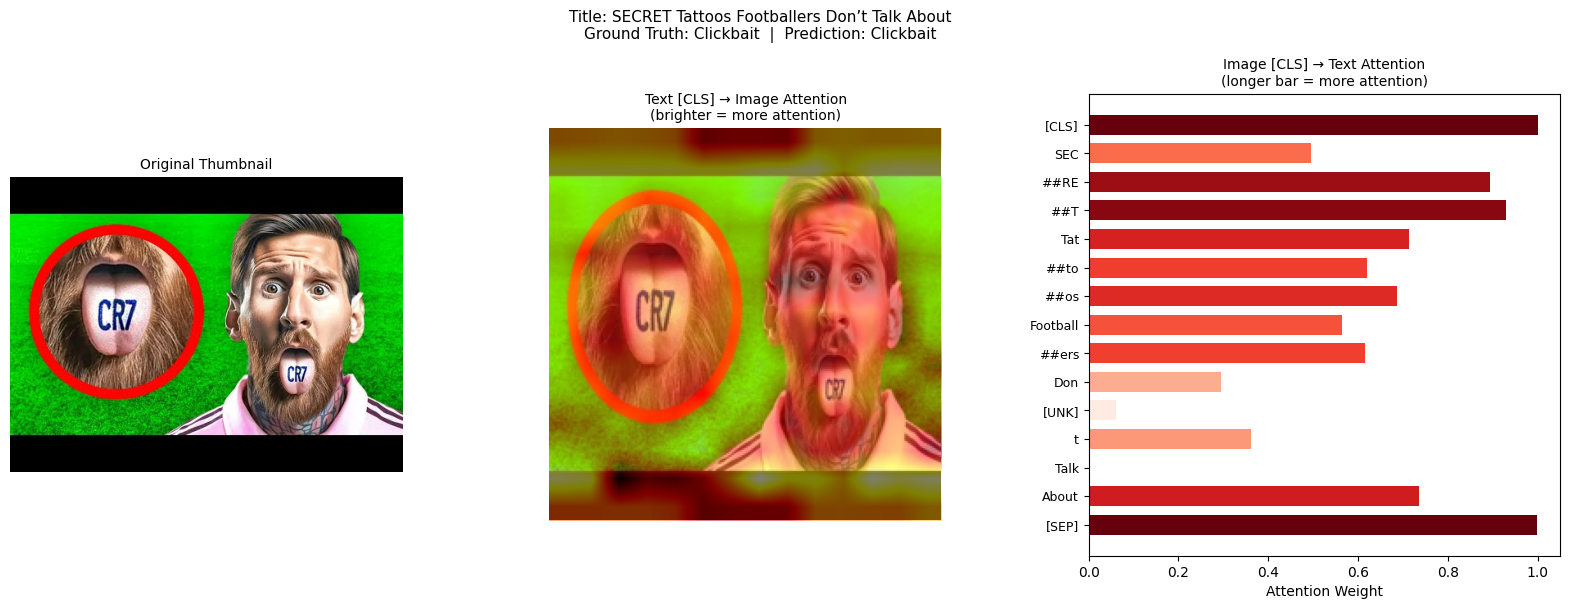

Saved: /content/drive/MyDrive/clickbait_project/viz_normal.png


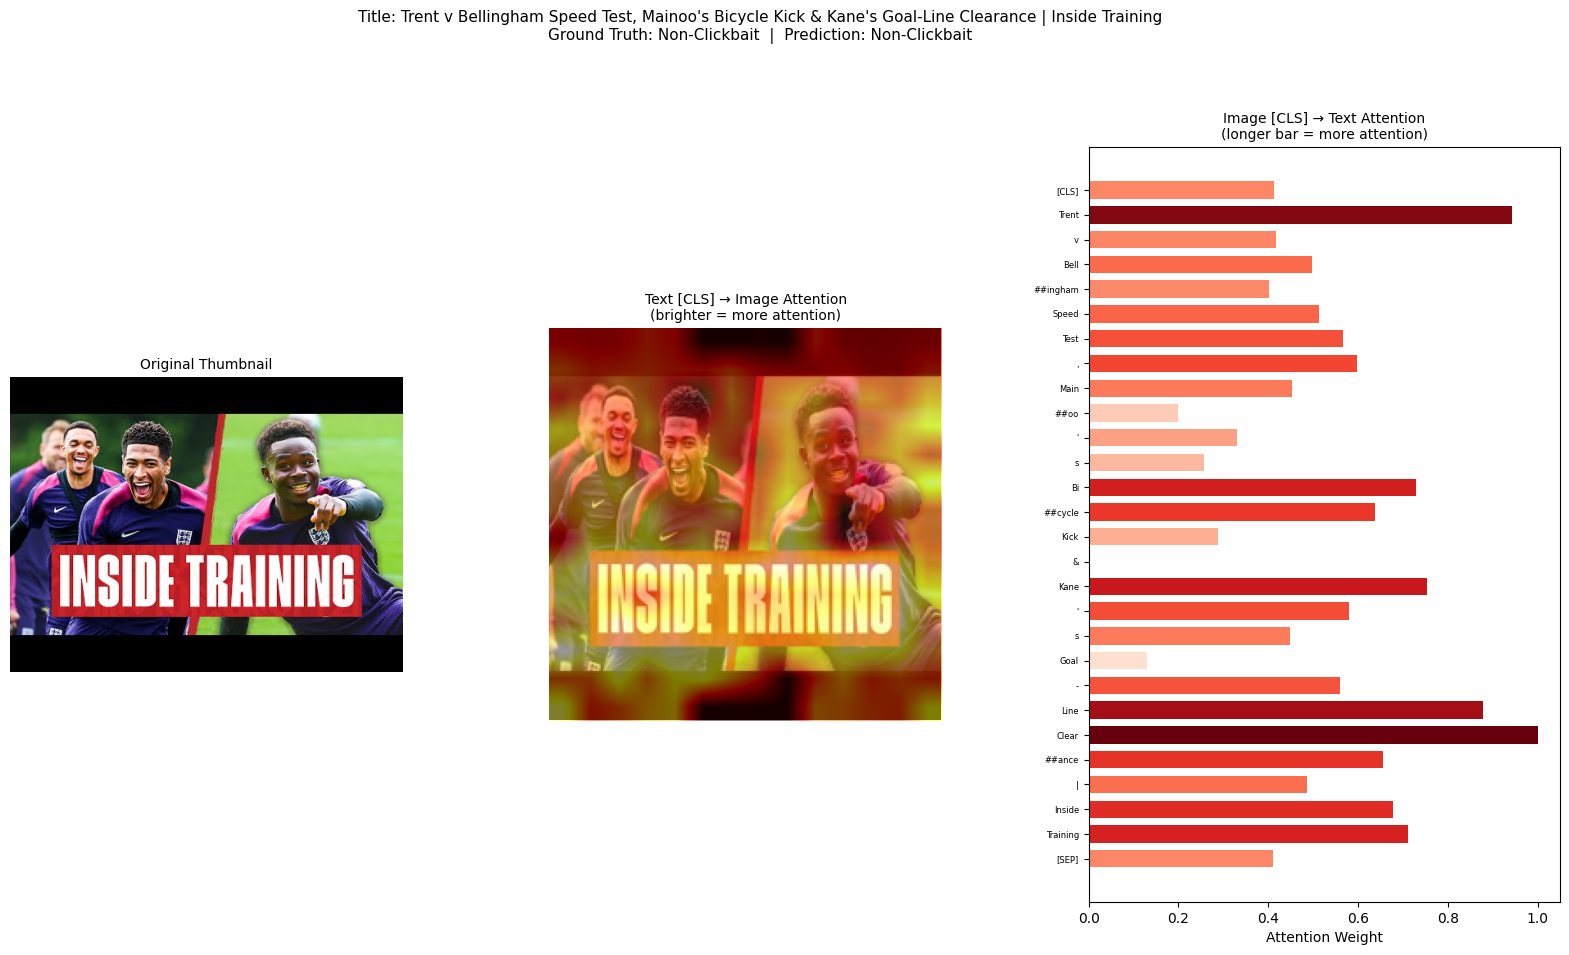

In [23]:
def visualize_cross_attention(model, tokenizer, image_processor,
                             sample_row, device, img_dir, save_path=None):
    model.eval()
    title     = str(sample_row["title"])
    video_id  = sample_row["video_id"]
    label_str = "Clickbait" if int(sample_row["label"]) == 1 else "Non-Clickbait"

    enc = tokenizer(title, max_length=128, padding="max_length",
                    truncation=True, return_tensors="pt")
    ids  = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    tokens   = tokenizer.convert_ids_to_tokens(ids[0].cpu().tolist())
    real_len = int(mask[0].sum().item())
    tokens   = tokens[:real_len]

    image = Image.open(f"{img_dir}/{video_id}.jpg").convert("RGB")
    pv    = image_processor(images=image, return_tensors="pt")["pixel_values"].to(device)

    with torch.no_grad():
        logits, t2i_w, i2t_w = model(input_ids=ids, attention_mask=mask, pixel_values=pv)

    pred_str = "Clickbait" if logits.argmax(1).item() == 1 else "Non-Clickbait"
    t2i_np, i2t_np = t2i_w.cpu().numpy()[0], i2t_w.cpu().numpy()[0]

    NUM_PATCHES = 14
    fig_h = max(6, real_len * 0.35)
    fig   = plt.figure(figsize=(20, fig_h))
    gs    = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.35)
    ax0, ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

    fig.suptitle(f"Title: {title}\nGround Truth: {label_str}  |  Prediction: {pred_str}",
                 fontsize=11, y=1.02)

    # Original image
    ax0.imshow(image); ax0.set_title("Original Thumbnail", fontsize=10); ax0.axis("off")

    # Text → Image attention heatmap
    img_attn = t2i_np[0, 1:NUM_PATCHES**2+1].reshape(NUM_PATCHES, NUM_PATCHES)
    img_attn = (img_attn - img_attn.min()) / (img_attn.max() - img_attn.min() + 1e-8)
    ax1.imshow(image.resize((224, 224)))
    ax1.imshow(img_attn, cmap="hot", alpha=0.5, extent=[0, 224, 224, 0], interpolation="bilinear")
    ax1.set_title("Text [CLS] → Image Attention\n(brighter = more attention)", fontsize=10)
    ax1.axis("off")

    # Image → Text attention bar chart
    i2t_row = i2t_np[0, :real_len]
    i2t_row = (i2t_row - i2t_row.min()) / (i2t_row.max() - i2t_row.min() + 1e-8)
    ax2.barh(range(real_len), i2t_row, color=plt.cm.Reds(i2t_row), height=0.7)
    ax2.set_yticks(range(real_len))
    ax2.set_yticklabels(tokens, fontsize=max(6, min(9, 180 // real_len)))
    ax2.invert_yaxis()
    ax2.set_title("Image [CLS] → Text Attention\n(longer bar = more attention)", fontsize=10)
    ax2.set_xlabel("Attention Weight"); ax2.set_xlim(0, 1.05)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

# Visualize one clickbait and one non-clickbait sample
ca_model.load_state_dict(torch.load(CA_SAVE, map_location=device))

visualize_cross_attention(ca_model, tokenizer, image_processor,
    test_df[test_df["label"]==1].iloc[0], device, IMG_DIR,
    save_path=f"{BASE_DIR}/viz_clickbait.png")

visualize_cross_attention(ca_model, tokenizer, image_processor,
    test_df[test_df["label"]==0].iloc[0], device, IMG_DIR,
    save_path=f"{BASE_DIR}/viz_normal.png")


---
## 12. References

1. Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*, NAACL 2019  
2. Dosovitskiy et al., *An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale*, ICLR 2021  
3. Lu et al., *ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision & Language Tasks*, NeurIPS 2019  
